In [1]:
import os
import time
import joblib
import logging
import pandas as pd
import numpy as np
import shap
from matplotlib import pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import MaxAbsScaler
logging.basicConfig(level=logging.INFO)

In [2]:
def load_data(input_path):
    logging.info("Loading data...")
    df = pd.read_csv(os.path.join(input_path, 'telephish.csv'), low_memory=False)
    return df

In [3]:
def preprocess_data(df):
    logging.info("Preprocessing data...")

    # Ensure boolean features are integers
    bool_features = ['is_forwarded', 'is_bot', 'has_media', 'has_text',
                     'is_reply', 'language_match','username_matches_language']
    for feature in bool_features:
        df[feature] = df[feature].astype(int)

    # Convert message time to categorical parts of the day
    df['time_of_day'] = df.apply(categorize_time, axis=1)
    df = pd.get_dummies(df, columns=['time_of_day'])

    return df

In [4]:
def categorize_time(row):
    """Categorize the time of day based on the message timestamp."""
    hour = pd.to_datetime(row['time']).hour
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Night'
    else:
        return 'Midnight'

In [5]:
def prepare_features(df, features):
    """Prepare features and target variables for modeling, including deduplication."""
    logging.info("Preparing features and target variables...")

    initial_row_count = len(df)

    # Deduplicate based on selected features
    df_dedup = df.drop_duplicates(subset=features)
    dedup_row_count = len(df_dedup)

    # Calculate the number of rows dropped
    rows_dropped = initial_row_count - len(df_dedup)
    logging.info(f"Number of duplicate rows dropped: {rows_dropped}")

    # Prepare feature matrix X, target vector y, and sample IDs
    X = df_dedup[features]
    y = df_dedup['is_phishing']
    sample_ids = df_dedup["sample_ids"] 
    category = df_dedup["category"]
    
    
    # Check for missing values in features (X)
    missing_in_X = X.isnull().sum()
    missing_columns_X = missing_in_X[missing_in_X > 0].index.tolist()

    if missing_columns_X:
        logging.warning(f"Columns with missing values in X: {missing_columns_X}")
        for col in missing_columns_X:
            missing_rows = X[X[col].isnull()].index.tolist()
            # logging.warning(f"Column '{col}' has missing values in rows: {missing_rows}")
        # problematic_column = missing_columns_X[0]
        # Drop rows where the problematic column has missing values
        df_clean = df_dedup.dropna(subset=missing_columns_X).reset_index(drop=True)
        clean_row_count = len(df_clean)
        rows_dropped_missing = dedup_row_count - clean_row_count
        logging.info(f"Number of rows dropped due to missing values: {rows_dropped_missing}")
        logging.info(f"Number of rows after dropping missing values: {clean_row_count}")
        
        # Update X, y, category and sample_ids after dropping
        X = df_clean[features]
        y = df_clean['is_phishing']
        sample_ids = df_clean["sample_ids"] 
        category = df_clean["category"]

    # Check for missing values in target vector (y)
    if y.isnull().any():
        missing_rows_y = y[y.isnull()].index.tolist()
        logging.warning(f"Target vector 'y' has missing values in rows: {missing_rows_y}")
    

    return X, y, sample_ids, category

In [6]:
def build_and_evaluate_model(X, y, sample_ids, category, path_prefix):
    
    numerical_features = [
        'message_length', 
        'url_count', 
        'total_messages', 
        'unique_users_per_group_message', 
        'messages_repeat_by_user',
        'formatted_text_count'
    ]
    
    param_grid = {
        'n_estimators': [100, 200, 500],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'class_weight': ['balanced', 'balanced_subsample']
    }
    model_to_tune = RandomForestClassifier(random_state=0)
    
    
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    
    outer_confusion_matrices = []
    outer_precision_list = []
    outer_recall_list = []
    outer_f1_list = []
    
    # Lists for sensitivity, specificity, and g-mean
    outer_sensitivity_list = []
    outer_specificity_list = []
    outer_gmean_list = []
    
    y_true_list = []
    y_pred_list = []
    sample_id_list = []
    fold_data_list = []
    best_params_list = []
    scaler_max_abs_list = []
    
    for i, (outer_train_index, outer_test_index) in enumerate(outer_cv.split(X, y)):
        X_outer_train = X.iloc[outer_train_index].reset_index(drop=True)
        X_outer_test = X.iloc[outer_test_index].reset_index(drop=True)
        y_outer_train = y.iloc[outer_train_index].reset_index(drop=True)
        y_outer_test = y.iloc[outer_test_index].reset_index(drop=True)
        sample_ids_outer_test = sample_ids.iloc[outer_test_index].reset_index(drop=True)
        category_outer_test = category.iloc[outer_test_index].reset_index(drop=True)
    
        # Fit MaxAbsScaler on X_outer_train[numerical_features]
        scaler = MaxAbsScaler()
        scaler.fit(X_outer_train[numerical_features])

        # Collect max absolute values
        scaler_max_abs_list.append(scaler.max_abs_)

        # Transform numerical features
        X_outer_train_scaled = X_outer_train.copy()
        X_outer_test_scaled = X_outer_test.copy()
        X_outer_train_scaled[numerical_features] = scaler.transform(
            X_outer_train[numerical_features]
        )
        X_outer_test_scaled[numerical_features] = scaler.transform(
            X_outer_test[numerical_features]
        )
    
        # Inner cross-validation for parameter search on the current outer fold
        model = GridSearchCV(
            estimator=model_to_tune, param_grid=param_grid, cv=inner_cv, n_jobs=-1, 
    scoring='f1_macro'
        )
        model.fit(X_outer_train_scaled, y_outer_train)
    
        # Save best parameters from this fold
        best_params_list.append(model.best_params_)
    
        y_pred = model.predict(X_outer_test_scaled)
    
        confusion_matrix_values = confusion_matrix(y_outer_test, y_pred)
        outer_confusion_matrices.append(confusion_matrix_values)
    
        # Calculate sensitivity, specificity, and g-mean
        # confusion_matrix_values = [[TN, FP],
        #                            [FN, TP]]
        TN = confusion_matrix_values[0, 0]
        FP = confusion_matrix_values[0, 1]
        FN = confusion_matrix_values[1, 0]
        TP = confusion_matrix_values[1, 1]
        
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        gmean = np.sqrt(sensitivity * specificity)
        
        outer_sensitivity_list.append(sensitivity)
        outer_specificity_list.append(specificity)
        outer_gmean_list.append(gmean)

        # Precision, recall, f1
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_outer_test, y_pred, average=None)
        outer_precision_list.append(precision)
        outer_recall_list.append(recall)
        outer_f1_list.append(f1)
    
        y_true_list.extend(y_outer_test)
        y_pred_list.extend(y_pred)
        sample_id_list.extend(sample_ids_outer_test)
    
        y_true_list.extend(y_outer_test)
        y_pred_list.extend(y_pred)
        sample_id_list.extend(sample_ids_outer_test)
    
        # print(f"Outer Fold {i+1} Confusion Matrix:\n{outer_confusion_matrices[-1]}")
        print(pd.DataFrame(confusion_matrix_values,
                                  index=['Non-Malicious (Negative)', 'Malicious (Positive)'],
                                  columns=['Predicted Non-Malicious', 'Predicted Malicious']))
        for j, (p, r, f_val) in enumerate(zip(precision, recall, f1)):
            label = 'Malicious (Positive)' if j == 1 else 'Non-Malicious (Negative)'
            print(
                f"Outer Fold {i+1} Class {label} Precision: {p:.3f}, Recall: {r:.3f}, "f"F1-score: {f_val:.3f}")
            
        print(f"Sensitivity (TPR): {sensitivity:.3f}")
        print(f"Specificity (TNR): {specificity:.3f}")
        print(f"G-mean: {gmean:.3f}\n")
    
        # Save fold predictions
        fold_data = X_outer_test.copy()
        fold_data['sample_ids'] = sample_ids_outer_test
        fold_data['category'] = category_outer_test
        fold_data['actual'] = y_outer_test
        fold_data['predicted'] = pd.Series(y_pred)
        fold_data.to_csv(f"{path_prefix}random_forest_predictions_fold{i+1}.csv", index=False)
        fold_data_list.append(fold_data)
    
    # Save the predicted values for all folds
    fold_data_all = pd.concat(fold_data_list, axis=0).reset_index(drop=True)
    fold_data_all.to_csv(f"{path_prefix}random_forest_predictions_all.csv", index=False)
    
    # Aggregate best parameters from each fold
    best_params_df = pd.DataFrame(best_params_list)
    # Choose the parameters that appear most frequently
    best_params = best_params_df.mode().iloc[0].to_dict()
    
    
    param_types = {
        'n_estimators': int,
        'max_depth': lambda x: int(x) if not pd.isnull(x) else None,
        'min_samples_split': int,
        'criterion': str,
        'max_features': lambda x: x if x is None else str(x),
        'class_weight': lambda x: x if x is None else str(x)
    }
    
    for param, param_type in param_types.items():
        if param in best_params:
            best_params[param] = param_type(best_params[param])
    
   # Aggregate max absolute values from all folds
    scaler_max_abs_array = np.array(scaler_max_abs_list)
    aggregated_max_abs = np.mean(scaler_max_abs_array, axis=0)

    max_abs_df = pd.DataFrame({
        'feature': numerical_features,
        'max_abs': aggregated_max_abs
    })
    max_abs_df.to_csv(f"{path_prefix}scaler_max_abs_values.csv", index=False)

    # Fit final scaler on entire dataset for future use
    final_scaler = MaxAbsScaler()
    final_scaler.fit(X[numerical_features])
    
    joblib.dump(final_scaler, f"{path_prefix}scaler.pkl")
    
    # Transform the entire dataset
    X_scaled = X.copy()
    X_scaled[numerical_features] = final_scaler.transform(X[numerical_features])
    
    start_time = time.time()  # Record the start time
    
    # Retrain the final model on the entire dataset using the best hyperparameters
    model_final = RandomForestClassifier(**best_params, random_state=0)
    model_final.fit(X_scaled, y)
    
    end_time = time.time()  # Record the end time
    duration = end_time - start_time  
    hours, rem = divmod(duration, 3600)
    minutes, seconds = divmod(rem, 60)
    print(f"\nTotal Execution Time: {int(hours)}h {int(minutes)}m {seconds:.2f}s")
    
    # Save the final model
    joblib.dump(model_final, f"{path_prefix}random_forest_model.pkl")
    
    # Save the final model parameters
    model_params = model_final.get_params()
    with open(f"{path_prefix}random_forest_model_params.txt", 'w') as f:
        for param, value in model_params.items():
            f.write(f"{param}: {value}\n")
    
    # Compute average precision, recall, and F1-score for each class across all folds
    average_precision = np.mean(outer_precision_list, axis=0)
    average_recall = np.mean(outer_recall_list, axis=0)
    average_f1 = np.mean(outer_f1_list, axis=0)
    
    std_precision = np.std(outer_precision_list, axis=0)
    std_recall = np.std(outer_recall_list, axis=0)
    std_f1 = np.std(outer_f1_list, axis=0)

    print("\nAverage and Standard Deviation of Precision, Recall, and F1-score Across All Folds:")
    for j in range(len(average_precision)):
        label = 'Malicious (Positive)' if j == 1 else 'Non-Malicious (Negative)'
        print(
            f"Class {label} - Precision: {average_precision[j]:.3f} ± {std_precision[j]:.3f}, "
            f"Recall: {average_recall[j]:.3f} ± {std_recall[j]:.3f}, "
            f"F1-score: {average_f1[j]:.3f} ± {std_f1[j]:.3f}"
        )
        
    # Compute average and std for sensitivity, specificity, g-mean
    avg_sensitivity = np.mean(outer_sensitivity_list)
    std_sensitivity = np.std(outer_sensitivity_list)
    avg_specificity = np.mean(outer_specificity_list)
    std_specificity = np.std(outer_specificity_list)
    avg_gmean = np.mean(outer_gmean_list)
    std_gmean = np.std(outer_gmean_list)
    
    print("\nAverage and Standard Deviation of Sensitivity, Specificity, and G-mean Across All Folds:")
    print(f"Sensitivity: {avg_sensitivity:.3f} ± {std_sensitivity:.3f}")
    print(f"Specificity: {avg_specificity:.3f} ± {std_specificity:.3f}")
    print(f"G-mean: {avg_gmean:.3f} ± {std_gmean:.3f}")
        

    # #--------------------------------------------------------------------------
    # # SHAP on the final Model
    # #--------------------------------------------------------------------------
    # explainer = shap.TreeExplainer(model_final)
    # X_for_shap = X_scaled  
    # shap_values = explainer.shap_values(X_for_shap)
    # 
    # for class_idx in range(shap_values.shape[2]):
    #     shap.summary_plot(shap_values[:, :, class_idx], X_for_shap, show=False)
    #     plt.subplots_adjust(left=0.07, right=0.95, top=0.95, bottom=0.07)
    #     plt.show()


In [7]:
def main():
    save_path = 'results/'
    input_path = '../../../data/'
    
    os.makedirs(save_path, exist_ok=True)
    df = load_data(input_path)
    df = preprocess_data(df) 
    
    # Selected features
    selected_features = [
        'is_bot', 'message_length', 'has_media', 'unique_users_per_group_message',
        'is_reply', 'url_count', 'total_messages', 'normalized_days_until_first_post',
        'language_match', 'messages_repeat_by_user', 'username_matches_language', 'formatted_text_count'] 
    X_selected, y_selected, sample_ids_selected, category_selected = prepare_features(df, selected_features) # Prepare the data with selected features

    print(np.unique(y_selected, return_counts=True))
    build_and_evaluate_model(X_selected, y_selected, sample_ids_selected, category_selected, save_path)

INFO:root:Loading data...
INFO:root:Preprocessing data...
INFO:root:Preparing features and target variables...
INFO:root:Number of duplicate rows dropped: 7315
INFO:root:Number of rows dropped due to missing values: 1017
INFO:root:Number of rows after dropping missing values: 49877


(array([False,  True]), array([48880,   997]))
                          Predicted Non-Malicious  Predicted Malicious
Non-Malicious (Negative)                     9752                   24
Malicious (Positive)                           70                  130
Outer Fold 1 Class Non-Malicious (Negative) Precision: 0.993, Recall: 0.998, F1-score: 0.995
Outer Fold 1 Class Malicious (Positive) Precision: 0.844, Recall: 0.650, F1-score: 0.734
Sensitivity (TPR): 0.650
Specificity (TNR): 0.998
G-mean: 0.805
                          Predicted Non-Malicious  Predicted Malicious
Non-Malicious (Negative)                     9749                   27
Malicious (Positive)                           59                  141
Outer Fold 2 Class Non-Malicious (Negative) Precision: 0.994, Recall: 0.997, F1-score: 0.996
Outer Fold 2 Class Malicious (Positive) Precision: 0.839, Recall: 0.705, F1-score: 0.766
Sensitivity (TPR): 0.705
Specificity (TNR): 0.997
G-mean: 0.838
                          Predicted

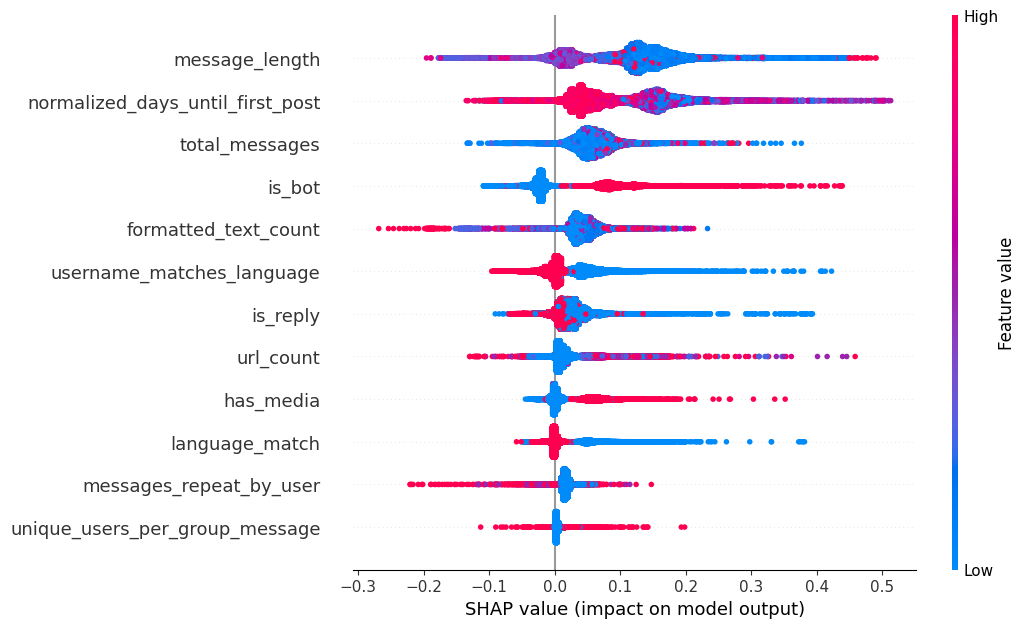

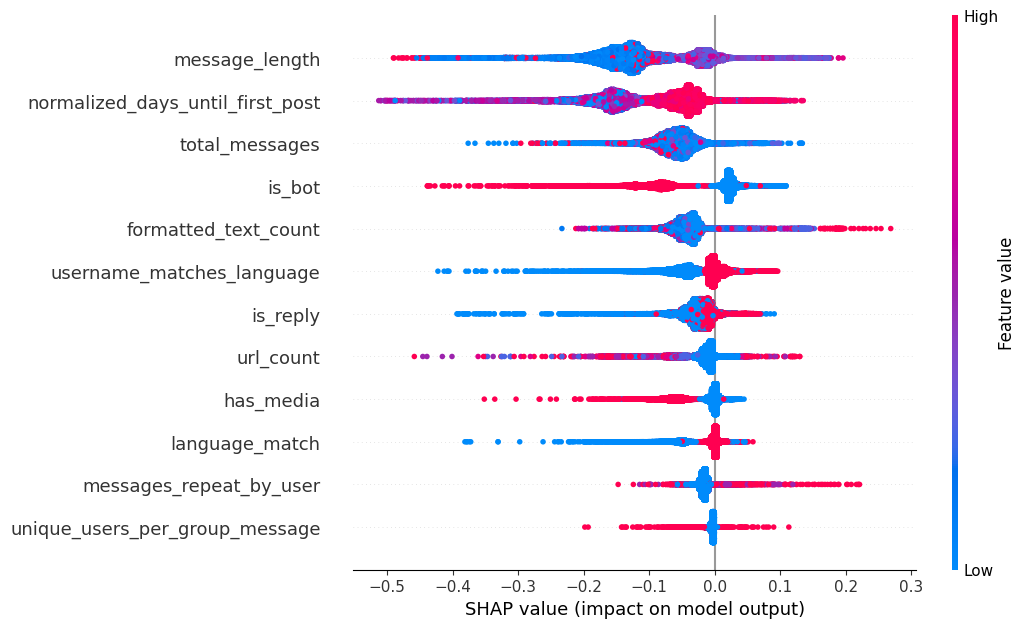

In [8]:
if __name__ == '__main__':
    main()